In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
from scipy.stats import pearsonr
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH, CONNECTOME_PRE_SYN_TABLE_PATH, SPINE_TABLE_OUTGOING
from neuron_custom_features import calc_spines_features, calc_sk_length_in_column
from spines_utils import filter_valid_neuron_w_spines, split_syn_mat_by_type_four, generate_shuffles
from plot_utils import ex_color, inh_color
from spine_pref_utils import per_neuron_spine_ratio, mean_input_outdegree, build_subnet_spine_ratio_df
from stats_corr import add_reg_line, p_to_stars
from figures_utils import add_panel_label, plot_nested_cylinders
from connectome_types import SPINE_TABLE

In [3]:
neurons_df = load_neurons_table()
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
neuron_clf_type = df[['root_id', 'clf_type']].set_index('root_id').to_dict(orient='index')
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

spine_df_outgoing = pd.read_csv(SPINE_TABLE_OUTGOING)
outgoing_syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_PRE_SYN_TABLE_PATH)
outgoing_syn_with_tags = outgoing_syn_df[outgoing_syn_df.id_.isin(spine_df_outgoing.target_id)].copy()
outgoing_syn_with_tags['tag'] = outgoing_syn_with_tags.id_.map(spine_df_outgoing.set_index('target_id').tag)

EE, EI, IE, II, ex_idx, inh_idx = split_syn_mat_by_type_four(filtered_bin_mat, filtered_mapping, neuron_clf_type)

ex_syn_tags = syn_with_tags[syn_with_tags.pre_clf_type == 'E']
ii_syn_tags = syn_with_tags[(syn_with_tags.pre_clf_type == 'I') & (syn_with_tags.post_clf_type == 'I')]

ex_neurons = ex_neurons.copy()
inh_neurons = inh_neurons.copy()

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:14<00:00, 93.27it/s] 


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


In [4]:
main_feature = 'spine'

e_all_stats = per_neuron_spine_ratio(ex_syn_tags, ex_neurons.root_id.tolist())
ii_stats = per_neuron_spine_ratio(ii_syn_tags, inh_neurons.root_id.tolist())

ex_neurons[f'outgoing_{main_feature}_ratio_all'] = ex_neurons.root_id.map(e_all_stats['ratio'])
inh_neurons[f'outgoing_{main_feature}_ratio_II'] = inh_neurons.root_id.map(ii_stats['ratio'])

REAL_BLOCKS = {'EE': EE, 'EI': EI, 'IE': IE, 'II': II}
BLOCK_COL_IDX = {'EE': ex_idx, 'IE': ex_idx, 'EI': inh_idx, 'II': inh_idx}
all_idx = sorted(filtered_mapping.keys())
ex_od_df, inh_od_df = mean_input_outdegree(
    REAL_BLOCKS, BLOCK_COL_IDX, filtered_mapping, df,
    full_mat=filtered_bin_mat, all_idx=all_idx)

ex_neurons = ex_neurons.merge(
    ex_od_df[['root_id', 'mean_input_outdegree_EE', 'mean_input_outdegree_IE', 'mean_input_outdegree_full']],
    on='root_id', how='left')
inh_neurons = inh_neurons.merge(
    inh_od_df[['root_id', 'mean_input_outdegree_EI', 'mean_input_outdegree_II', 'mean_input_outdegree_full']],
    on='root_id', how='left')

calc_sk_length_in_column(ex_neurons)

# shuffled controls for block model
N_SHUFFLES = 100
shuffles_block = generate_shuffles(
    filtered_bin_mat, filtered_mapping, neuron_clf_type,
    shuffle_mode='cfg', amount=N_SHUFFLES, shuffle_preserve_EI=True)

def add_sharing_prop_to_shuffles(shuffles):
    results = []
    for sh_mat in shuffles:
        EE_s, EI_s, IE_s, II_s, ex_idx_s, inh_idx_s = split_syn_mat_by_type_four(
            sh_mat, filtered_mapping, neuron_clf_type)
        blocks_s = {'EE': EE_s, 'EI': EI_s, 'IE': IE_s, 'II': II_s}
        col_idx_s = {'EE': ex_idx_s, 'IE': ex_idx_s, 'EI': inh_idx_s, 'II': inh_idx_s}
        ex_od_s, inh_od_s = mean_input_outdegree(
            blocks_s, col_idx_s, filtered_mapping, df,
            full_mat=sh_mat, all_idx=sorted(filtered_mapping.keys()))
        results.append((ex_od_s, inh_od_s))
    return results

block_results = add_sharing_prop_to_shuffles(shuffles_block)
shuffled_blocked_ex_dfs = [r[0] for r in block_results]
shuffled_blocked_inh_dfs = [r[1] for r in block_results]

e_control_full = [val for df_ in shuffled_blocked_ex_dfs for val in df_['mean_input_outdegree_full']]
i_control_full = [val for df_ in shuffled_blocked_inh_dfs for val in df_['mean_input_outdegree_full']]

Max x: 735.1817610250125, Min x: 604.9913590104155
Max z: 1023.8400000000003, Min z: 805.5600000000003


Shuffling [cfg]: 100%|██████████| 100/100 [00:08<00:00, 12.43it/s]


In [5]:
plt.rcParams['font.size'] = 16
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['font.family'] = 'Arial'

reg_text_font_size = 12
featues_small_font_size = 12

sharing_prop_label = "Shared input strength/neuron\n(mean out-degree of all presynaptic neurons)"
sharing_prop_label_short = "Shared input strength"

spiny_color  = '#7C3AED'
aspiny_color = '#059669'

# E & I full configuration
use_ee = False
sharing_feature = 'mean_input_outdegree_full'
inh_sharing_feature = sharing_feature
spine_pref_feature = f'outgoing_{main_feature}_ratio_all'
e_control = e_control_full
i_control = i_control_full
dist_bins = np.arange(0, max(ex_od_df[sharing_feature].max(), inh_od_df[inh_sharing_feature].max()) + 40, 20)
e_label = 'E'
i_label = 'I'

In [6]:
purples = ['#C4B5FD', '#A17EFC', '#7C3AED']
greens = ['#6EE7B7', '#34D399', '#10B981', '#059669', '#047857']
scatter_palette = {
    '23P': spiny_color, '4P': purples[1], '5P-IT': purples[0],
    '5P-NP': greens[4], '5P-PT': greens[3], '6P-CT': greens[2],
    '6P-IT': greens[1], '6P-U': greens[0],
}

x_features = ['axon_local_path_length', spine_pref_feature, 'dendrite_local_path_length', 'ds_spine_density']
x_feature_labels = ['Local\naxonal\nlength (\u03bcm)',
                    '% of output\nsynapses on\ntarget spines',
                    'Local\ndendritic\nlength (\u03bcm)',
                    'Density of\nspinous synapses\n(syn/\u03bcm)']
x_feature_labels2 = ['Local axonal length\n(\u03bcm)',
                     '% of output synapses on\ntarget spines',
                     'Local dendritic length\n(\u03bcm)',
                     'Density of spinous synapses\n(syn/\u03bcm)']

feature_color_master = {
    sharing_feature: 'black',
    spine_pref_feature: spiny_color,
    'axon_local_path_length': spiny_color,
    'ds_spine_density': aspiny_color,
    'dendrite_local_path_length': aspiny_color,
}
color_palette_bar_plot = {
    label: feature_color_master[feature]
    for feature, label in zip(x_features, x_feature_labels)
}

pearson_corrs = []
pearson_corr_p_vals_str = []
for x in x_features:
    valid_data = ex_neurons[[x, sharing_feature]].dropna()
    r, p_val = pearsonr(valid_data[x], valid_data[sharing_feature])
    pearson_corrs.append(r)
    pearson_corr_p_vals_str.append(p_to_stars(p_val))

ex_neurons_sorted = ex_neurons.sort_values('cell_type')
ignore_cell_type = ['WM-P', 'Unsure E']
ex_neurons_sorted = ex_neurons_sorted[~ex_neurons_sorted['cell_type'].isin(ignore_cell_type)]
ex_neurons_sorted['cell_type'] = ex_neurons_sorted['cell_type'].cat.remove_unused_categories()

dist_features = x_features + [sharing_feature]
dist_feature_labels2 = x_feature_labels2 + [sharing_prop_label_short]
label_map = dict(zip(dist_features, dist_feature_labels2))

# Correlation heatmap data
features_5x5 = x_features + [sharing_feature]
labels_5x5 = x_feature_labels2 + [sharing_prop_label_short]
corr_matrix_5x5 = ex_neurons[features_5x5].corr(method='pearson')
annot_matrix_5x5 = np.empty_like(corr_matrix_5x5, dtype=object)
for i, feature_x in enumerate(features_5x5):
    for j, feature_y in enumerate(features_5x5):
        if i <= j:
            annot_matrix_5x5[i, j] = ''
        else:
            valid_data = ex_neurons[[feature_x, feature_y]].dropna()
            r, p_val = pearsonr(valid_data[feature_x], valid_data[feature_y])
            annot_matrix_5x5[i, j] = f'{r:.2f}\n{p_to_stars(p_val)}'
mask_5x5 = np.triu(np.ones_like(corr_matrix_5x5, dtype=bool))
corr_matrix_sliced = corr_matrix_5x5.iloc[1:, :-1]
annot_matrix_sliced = annot_matrix_5x5[1:, :-1]
mask_sliced = mask_5x5[1:, :-1]
y_labels_sliced = labels_5x5[1:]
x_labels_sliced = labels_5x5[:-1]

R=0.46 R^2: 0.21 slope: 0.03 intercept: 106.12, p=p=1.7e-60
R=0.47 R^2: 0.22 slope: 189.72 intercept: 78.01, p=p=1.9e-64
R=-0.07 R^2: 0.00 slope: -0.01 intercept: 185.73, p=p=0.019
R=0.06 R^2: 0.00 slope: 19.02 intercept: 159.77, p=p=0.045


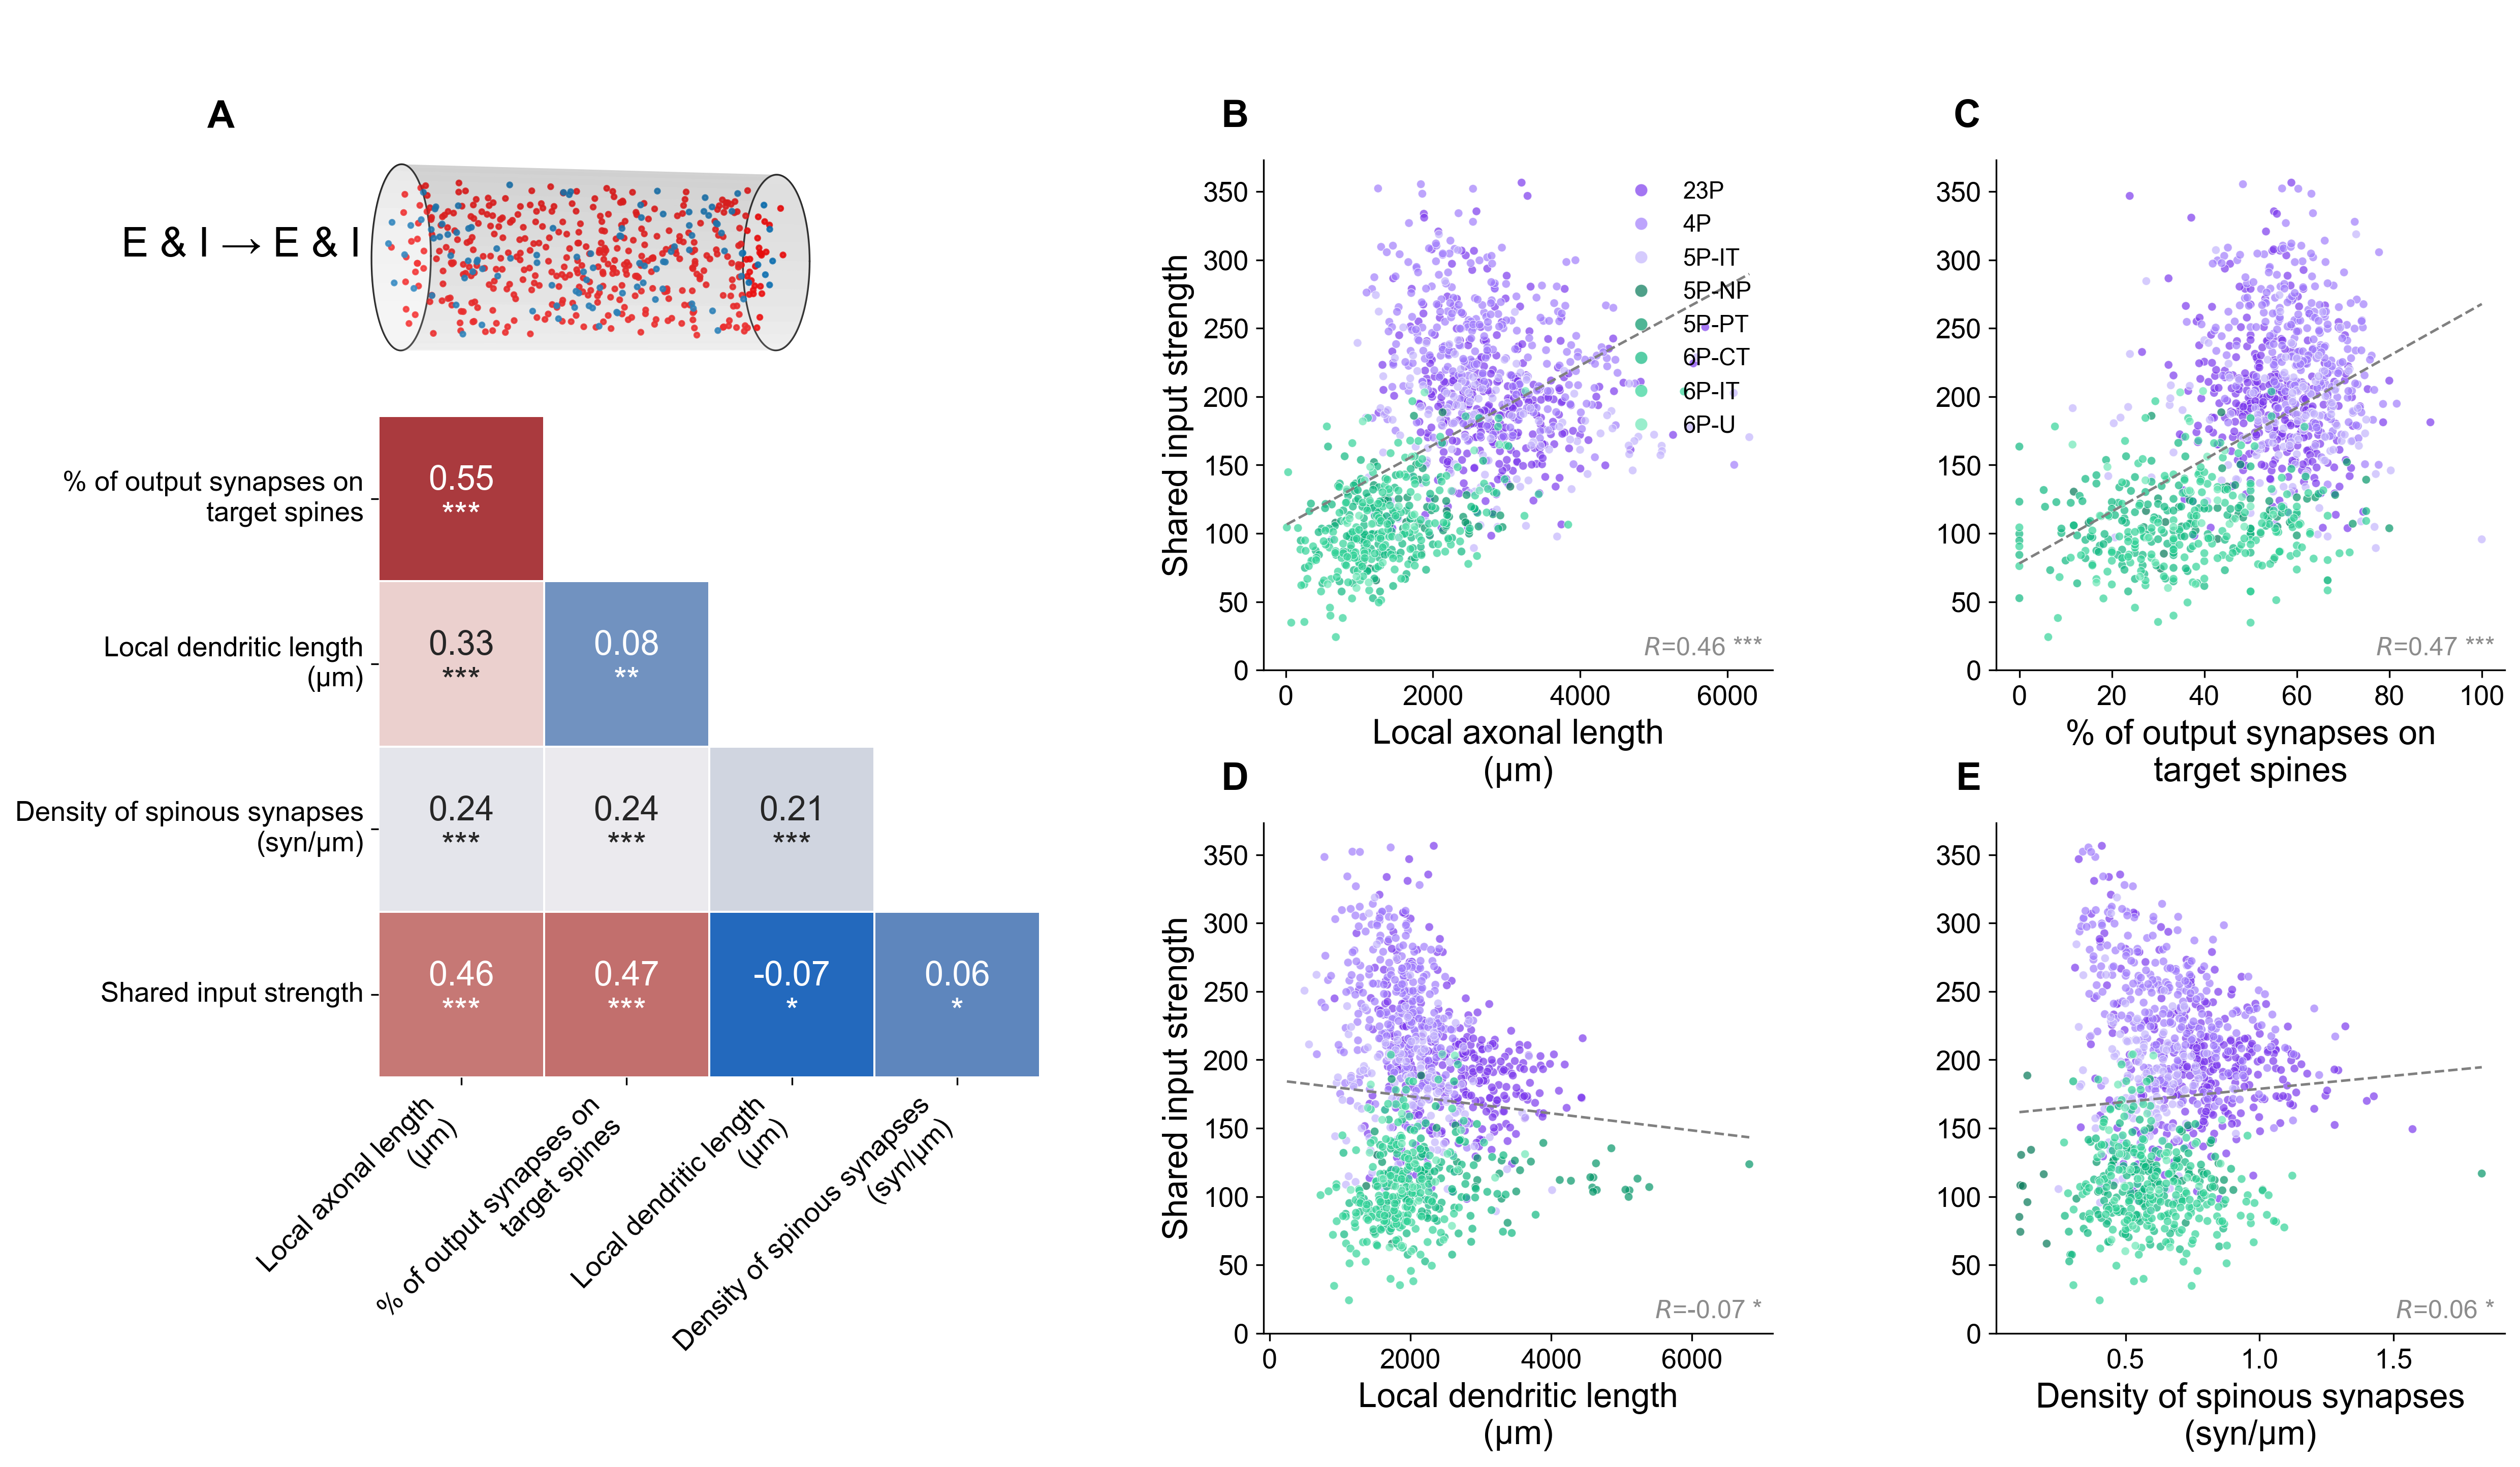

In [7]:
fig = plt.figure(figsize=(18, 10), dpi=300)
gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[1.3, 1, 1], wspace=0.4, hspace=0.3)

ax_hm = fig.add_subplot(gs[:, 0])
sns.heatmap(
    corr_matrix_sliced, annot=annot_matrix_sliced, fmt='', cmap='vlag',
    vmin=-0.0, vmax=0.55, mask=mask_sliced, cbar=False,
    xticklabels=x_labels_sliced, yticklabels=y_labels_sliced,
    square=True, linewidths=0.5, ax=ax_hm)
ax_hm.xaxis.tick_bottom()
ax_hm.set_xticklabels(x_labels_sliced, rotation=45, ha='right')
ax_hm.set_yticklabels(y_labels_sliced, rotation=0)

overlay_position = [0.075, 0.5, 0.25, 0.5]
ax_cyl = fig.add_axes(overlay_position, projection='3d')
ax_cyl.set_title('E & I \u2192 E & I', y=0.685, x=0.0)
plot_nested_cylinders(ax_cyl, show_outer=False, dot_size=5, n_dots=500)
ax_cyl.patch.set_alpha(0.0)
ax_cyl.set_zorder(10)
ax_cyl.view_init(elev=30, azim=0, roll=90)
ymin, ymax = ax_cyl.get_ylim()
ax_cyl.set_ylim(ymin, ymin + 0.7 * (ymax - ymin))

scatter_positions = [(0, 1), (0, 2), (1, 1), (1, 2)]
scatter_axes = []
for i, x in enumerate(x_features):
    row, col = scatter_positions[i]
    ax_sc = fig.add_subplot(gs[row, col])
    scatter_axes.append(ax_sc)
    sns.scatterplot(data=ex_neurons_sorted, x=x, y=sharing_feature, s=16, alpha=0.7, ax=ax_sc,
                    hue='cell_type', palette=scatter_palette, legend=(i == 0))
    ax_sc.set_ylabel(sharing_prop_label_short)
    ax_sc.set_xlabel(label_map[x])
    if col > 1:
        ax_sc.set_ylabel('')
    if i == 1:
        ax_sc.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0, symbol=''))
    if i == 0:
        ax_sc.legend(title='', loc='upper right', frameon=False, markerscale=1.5,
                     fontsize=featues_small_font_size - 1, ncol=1)
    add_reg_line(ex_neurons[x], ex_neurons[sharing_feature], ax=ax_sc, color='gray',
                 reg_text_font_size=reg_text_font_size, linestyle='--', linewidth=1.2, add_reg_text='r_only')
    ax_sc.spines[['top', 'right']].set_visible(False)
    ax_sc.set_ylim(bottom=0)

add_panel_label(ax_cyl, 'A', xy=(-0.01, 0.825))
add_panel_label(scatter_axes[0], 'B', xy=(-0.03, 1.05))
add_panel_label(scatter_axes[1], 'C', xy=(-0.03, 1.05))
add_panel_label(scatter_axes[2], 'D', xy=(-0.03, 1.05))
add_panel_label(scatter_axes[3], 'E', xy=(-0.03, 1.05))
plt.savefig('fig_s10.pdf', format='pdf', bbox_inches='tight')